# DeepLense Common Task I — Physics-Informed DenseNet161 (Tier-1 optimized)

This notebook is a DenseNet-only, submission-oriented pipeline for **Common Task I** and now includes the full **Tier-1 improvements** we discussed.

## What this notebook does
- Merges the provided `train/` and `val/` folders and rebuilds a **fresh stratified 90:10 split**.
- Uses **DenseNet161** as the main backbone.
- Uses a **physics-informed 3-channel input**:
  1. **asinh-stretched raw channel** for faint-arc visibility,
  2. **LensPINN-style edge channel** for localized perturbations,
  3. **high-pass residual channel** for substructure-sensitive morphology.
- Uses a **small-image stem** for DenseNet:
  - replaces the aggressive ImageNet-style `7×7, stride 2` entry convolution with a **`3×3, stride 1`** stem,
  - removes the initial max-pool,
  - preserves more spatial detail at **150×150** resolution where small substructure cues matter.
- Uses **`catavgmax` global pooling** so the classifier sees both:
  - average/global morphology,
  - strongest localized responses.
- Trains for **up to 40 epochs** with **patience 10** instead of stopping too early.
- Saves the **top-k checkpoints** and performs **top-k checkpoint ensembling** at final evaluation.
- Uses **D4 symmetry augmentation** in training and **D4 test-time augmentation (TTA)** in inference.
- Tracks **validation loss, accuracy, macro-F1, macro AUC, weighted AUC**, and **per-class AUC**.

## Why these changes
Your earlier notebook was already strong, so the goal here is **not** to rewrite DenseNet. The best next improvements are the ones that preserve the good baseline while giving the model a better chance to capture subtle lensing structure.

### 1) Small-image stem
DenseNet backbones pretrained on ImageNet start with early downsampling. That is good for large natural images, but for **150×150 lensing maps** it can throw away fine perturbations too early.  
This notebook replaces that stem with a gentler **`3×3 / stride 1`** entry and removes the first max-pool so more substructure survives into the dense blocks.

### 2) `catavgmax` pooling
For this task, some evidence is diffuse and global, while some evidence is highly localized.  
`catavgmax` pooling gives the head access to **both** kinds of cues instead of forcing a single average-pooled summary.

### 3) Longer training with moderate patience
Your curves were still improving late, so this version increases the training budget to **40 epochs** and uses **patience 10**.  
This is safer than making the optimizer much more aggressive.

### 4) Top-k checkpoint ensemble + D4 TTA
This is one of the most reliable inference-time upgrades:
- keep the best few checkpoints instead of trusting one epoch only,
- average predictions from multiple symmetry-equivalent views at inference.

That usually improves stability and often lifts macro AUC a bit without changing the training data.

## Submission note
Because the provided folder split was not 90:10, this notebook rebuilds a **fresh stratified 90:10 split** from the full labeled dataset so the reported validation metrics match the stated requirement.

In [ ]:
import sys

print("python:", sys.executable)

!{sys.executable} -m pip show torch torchvision torchaudio || true

!{sys.executable} -m pip uninstall -y torch torchvision torchaudio

!{sys.executable} -m pip install --no-cache-dir --force-reinstall \
    torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 \
    --index-url https://download.pytorch.org/whl/cu121

!{sys.executable} -m pip show torch torchvision torchaudio

In [1]:

import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("capability:", torch.cuda.get_device_capability(0))


torch: 2.4.1+cu121
torchvision: 0.19.1+cu121
cuda available: True
gpu: Tesla P100-PCIE-16GB
capability: (6, 0)


In [2]:
import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

x = torch.randn(2, 3, 150, 150, device="cuda")
conv = torch.nn.Conv2d(3, 16, kernel_size=3, padding=1).cuda()
y = conv(x)
print("conv output shape:", y.shape)

torch: 2.4.1+cu121
torchvision: 0.19.1+cu121
cuda available: True
gpu: Tesla P100-PCIE-16GB
capability: (6, 0)
conv output shape: torch.Size([2, 16, 150, 150])


In [3]:
import os
import gc
import json
import math
import copy
import heapq
import zipfile
import shutil
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

import timm
from timm.loss import LabelSmoothingCrossEntropy
from timm.utils import ModelEmaV2

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)


In [4]:
@dataclass
class CFG:
    # paths
    data_root: str | None = None
    output_dir: str = "./outputs_pinn"
    split_csv_dir: str = "./outputs_pinn/splits"
    ckpt_dir: str = "./outputs_pinn/checkpoints"

    # classes
    class_names: tuple = ("no", "sphere", "vort")

    # model
    model_name: str = "densenet161"
    pretrained: bool = True
    in_chans: int = 4
    use_small_image_stem: bool = True
    head_dropout: float = 0.20
    aux_head_dropout: float = 0.10

    # image
    img_size: int = 150
    normalize_to_minus1_1: bool = True

    # optimization
    epochs: int = 35
    warmup_epochs: int = 3
    batch_size: int = 8
    num_workers: int = 4
    lr: float = 2.5e-4
    min_lr: float = 1e-6
    weight_decay: float = 1e-4
    label_smoothing: float = 0.02
    grad_clip: float = 1.0
    use_amp: bool = True

    # training regularization
    use_ema: bool = True
    ema_decay: float = 0.9995
    early_stopping_patience: int = 10
    save_top_k: int = 5

    # augmentation on the base grayscale image
    use_d4_train_aug: bool = True
    use_translation_aug: bool = True
    max_shift_px: int = 6
    use_psf_aug: bool = True
    psf_prob: float = 0.40
    psf_sigma_range: tuple = (0.3, 1.2)
    use_noise_aug: bool = True
    noise_prob: float = 0.40
    noise_std_range: tuple = (0.003, 0.025)

    # physics channels
    use_asinh_raw: bool = True
    asinh_soften: float = 0.15
    dog_sigma_small: float = 1.0
    dog_sigma_large: float = 2.5
    edge_eps: float = 1e-6

    # physics-guided loss weights
    aux_phys_cls_weight: float = 0.25
    infer_aux_weight: float = 0.20
    kappa_consistency_weight: float = 0.08
    curl_weight: float = 0.03
    psi_tv_weight: float = 1e-4
    kappa_tv_weight: float = 5e-5

    # evaluation
    use_d4_tta: bool = True
    final_eval_top_k: int = 5

    # reproducibility
    seed: int = 42

cfg = CFG()
for p in [cfg.output_dir, cfg.split_csv_dir, cfg.ckpt_dir]:
    Path(p).mkdir(parents=True, exist_ok=True)
cfg


CFG(data_root=None, output_dir='./outputs_pinn', split_csv_dir='./outputs_pinn/splits', ckpt_dir='./outputs_pinn/checkpoints', class_names=('no', 'sphere', 'vort'), model_name='densenet161', pretrained=True, in_chans=4, use_small_image_stem=True, head_dropout=0.2, aux_head_dropout=0.1, img_size=150, normalize_to_minus1_1=True, epochs=35, warmup_epochs=3, batch_size=8, num_workers=4, lr=0.00025, min_lr=1e-06, weight_decay=0.0001, label_smoothing=0.02, grad_clip=1.0, use_amp=True, use_ema=True, ema_decay=0.9995, early_stopping_patience=10, save_top_k=5, use_d4_train_aug=True, use_translation_aug=True, max_shift_px=6, use_psf_aug=True, psf_prob=0.4, psf_sigma_range=(0.3, 1.2), use_noise_aug=True, noise_prob=0.4, noise_std_range=(0.003, 0.025), use_asinh_raw=True, asinh_soften=0.15, dog_sigma_small=1.0, dog_sigma_large=2.5, edge_eps=1e-06, aux_phys_cls_weight=0.25, infer_aux_weight=0.2, kappa_consistency_weight=0.08, curl_weight=0.03, psi_tv_weight=0.0001, kappa_tv_weight=5e-05, use_d4_tta

In [5]:

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [6]:

def find_dataset_root(explicit_root: str | None = None) -> Path:
    candidates = []
    if explicit_root is not None:
        candidates.append(Path(explicit_root))

    candidates += [
        Path("/kaggle/input/datasets/ashaeyx/common-task-dataset/dataset"),
        Path("/kaggle/input/datasets/arushhh/common-task-dataset/dataset"),
        Path("/kaggle/input/datasets/adityaaru/dataset-vii/dataset"),
        Path("/content/dataset"),
        Path("./dataset"),
        Path("."),
    ]

    def is_valid_root(p: Path) -> bool:
        return (p / "train").exists() and (p / "val").exists()

    for c in candidates:
        if is_valid_root(c):
            return c
        for sub in c.glob("**/*"):
            if sub.is_dir() and is_valid_root(sub):
                return sub

    raise FileNotFoundError(
        "Could not find dataset root containing train/ and val/ folders. "
        "Set CFG.data_root manually if needed."
    )


def list_image_files(folder: Path):
    exts = {".npy", ".npz", ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])


def build_full_dataframe(train_dir: Path, val_dir: Path, class_names: tuple[str, ...]) -> pd.DataFrame:
    rows = []
    for split_name, split_dir in [("provided_train", train_dir), ("provided_val", val_dir)]:
        for label, cls in enumerate(class_names):
            cls_dir = split_dir / cls
            files = list_image_files(cls_dir)
            rows.extend([
                {
                    "path": str(fp),
                    "label": label,
                    "class_name": cls,
                    "source_split": split_name,
                }
                for fp in files
            ])
    return pd.DataFrame(rows)


dataset_root = find_dataset_root(cfg.data_root)
train_dir = dataset_root / "train"
val_dir = dataset_root / "val"
print("Dataset root:", dataset_root)

full_df = build_full_dataframe(train_dir, val_dir, cfg.class_names)
print("Full dataset size:", len(full_df))
display(full_df.head())


Dataset root: /kaggle/input/datasets/adityaaru/dataset-vii/dataset
Full dataset size: 37500


,path,label,class_name,source_split
0,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train
1,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train
2,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train
3,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train
4,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train


In [7]:

train_df, val_df = train_test_split(
    full_df,
    test_size=0.10,
    random_state=cfg.seed,
    stratify=full_df["label"],
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

train_df["sample_id"] = train_df["path"].astype(str)
val_df["sample_id"] = val_df["path"].astype(str)

train_df.to_csv(Path(cfg.split_csv_dir) / "train_split.csv", index=False)
val_df.to_csv(Path(cfg.split_csv_dir) / "val_split.csv", index=False)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("\nTrain class counts:")
display(train_df.groupby("class_name").size())
print("\nVal class counts:")
display(val_df.groupby("class_name").size())


Train size: 33750
Val size  : 3750

Train class counts:


class_name
no        11250
sphere    11250
vort      11250
dtype: int64


Val class counts:


class_name
no        1250
sphere    1250
vort      1250
dtype: int64

In [8]:
# Artifact persistence + optional Hugging Face sync (TRAIN-ONLY VERSION)
from pathlib import Path

RUN_ROOT = Path(cfg.output_dir)
SPLIT_ROOT = Path(cfg.split_csv_dir)
CKPT_ROOT = Path(cfg.ckpt_dir)
BUNDLE_PATH = RUN_ROOT / "artifact_bundle.zip"

for p in [RUN_ROOT, SPLIT_ROOT, CKPT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

RUN_NAME = RUN_ROOT.name

# Kaggle secrets -> robust retrieval first; fall back to env vars
try:
    from kaggle_secrets import UserSecretsClient
    _user_secrets = UserSecretsClient()
except Exception:
    _user_secrets = None

def _get_secret(name: str, default=None):
    if _user_secrets is not None:
        try:
            value = _user_secrets.get_secret(name)
            if value is not None and value != "":
                return value
        except Exception:
            pass
    value = os.environ.get(name, default)
    return value

HF_TOKEN = _get_secret("HF_TOKEN")
HF_REPO_ID = _get_secret("HF_REPO_ID")
HF_REPO_TYPE = _get_secret("HF_REPO_TYPE", "dataset")
HF_ENABLE_SYNC = bool(HF_TOKEN and HF_REPO_ID)

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
if HF_REPO_ID:
    os.environ["HF_REPO_ID"] = HF_REPO_ID
os.environ["HF_REPO_TYPE"] = HF_REPO_TYPE

print("HF token found:", bool(HF_TOKEN))
print("HF repo id:", HF_REPO_ID)
print("HF repo type:", HF_REPO_TYPE)

def write_json(payload, path: str | Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)

def save_split_metadata(full_df: pd.DataFrame, train_df: pd.DataFrame, val_df: pd.DataFrame):
    full_df.to_csv(SPLIT_ROOT / "full_dataset_index.csv", index=False)
    train_df.to_csv(SPLIT_ROOT / "train_split.csv", index=False)
    val_df.to_csv(SPLIT_ROOT / "val_split.csv", index=False)

    meta = {
        "seed": int(cfg.seed),
        "split_strategy": "merge_provided_train_val_then_stratified_90_10",
        "num_total": int(len(full_df)),
        "num_train": int(len(train_df)),
        "num_val": int(len(val_df)),
        "class_names": list(cfg.class_names),
        "train_class_counts": train_df["class_name"].value_counts().sort_index().to_dict(),
        "val_class_counts": val_df["class_name"].value_counts().sort_index().to_dict(),
        "source_split_counts": full_df["source_split"].value_counts().sort_index().to_dict(),
    }
    write_json(meta, SPLIT_ROOT / "split_metadata.json")
    return meta

def save_run_config():
    cfg_path = RUN_ROOT / "run_config.json"
    write_json(asdict(cfg), cfg_path)
    return cfg_path

def save_training_tables(history, topk_heap):
    history_df = pd.DataFrame(history)
    history_path = RUN_ROOT / "training_history.csv"
    history_df.to_csv(history_path, index=False)

    topk_sorted = sorted(topk_heap, key=lambda x: x[0], reverse=True)
    topk_df = pd.DataFrame([
        {"macro_auc_ovr": float(metric), "checkpoint_path": str(path)}
        for metric, path in topk_sorted
    ])
    topk_path = RUN_ROOT / "topk_checkpoints.csv"
    topk_df.to_csv(topk_path, index=False)
    return history_df, topk_df, history_path, topk_path

def save_artifact_manifest(best_epoch=None, best_score=None):
    manifest = {
        "run_name": RUN_NAME,
        "output_dir": str(RUN_ROOT),
        "split_dir": str(SPLIT_ROOT),
        "ckpt_dir": str(CKPT_ROOT),
        "best_epoch": None if best_epoch is None else int(best_epoch),
        "best_macro_auc_ovr": None if best_score is None else float(best_score),
        "files_present": sorted([
            str(p.relative_to(RUN_ROOT))
            for p in RUN_ROOT.rglob("*") if p.is_file()
        ]),
    }
    manifest_path = RUN_ROOT / "artifact_manifest.json"
    write_json(manifest, manifest_path)
    return manifest_path

def package_artifacts():
    tmp_bundle = BUNDLE_PATH.with_suffix(".tmp.zip")
    keep_files = []
    for p in RUN_ROOT.rglob("*"):
        if not p.is_file():
            continue
        rel = p.relative_to(RUN_ROOT)
        if p.suffix in {".csv", ".json"}:
            keep_files.append((p, rel))
        elif p.suffix == ".pth" and (p.parent == CKPT_ROOT or p.parent == RUN_ROOT):
            keep_files.append((p, rel))

    with zipfile.ZipFile(tmp_bundle, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for src, rel in sorted(keep_files, key=lambda x: str(x[1])):
            zf.write(src, arcname=str(rel))

    tmp_bundle.replace(BUNDLE_PATH)
    return BUNDLE_PATH

def _get_hf_api():
    if not HF_ENABLE_SYNC:
        return None
    try:
        from huggingface_hub import HfApi, create_repo
    except Exception as e:
        print(f"[HF] huggingface_hub unavailable: {e}")
        return None

    try:
        create_repo(
            repo_id=HF_REPO_ID,
            repo_type=HF_REPO_TYPE,
            private=True,
            exist_ok=True,
            token=HF_TOKEN,
        )
    except Exception as e:
        print(f"[HF] repo create/check skipped: {e}")

    return HfApi(token=HF_TOKEN)

def sync_files_to_hf(paths, repo_prefix: str | None = None):
    if not HF_ENABLE_SYNC:
        return
    api = _get_hf_api()
    if api is None:
        return

    repo_prefix = RUN_NAME if repo_prefix is None else repo_prefix
    seen = set()
    for path in paths:
        if path is None:
            continue
        path = Path(path)
        if (not path.exists()) or (path in seen):
            continue
        seen.add(path)
        rel = path.relative_to(RUN_ROOT) if str(path).startswith(str(RUN_ROOT)) else Path(path.name)
        path_in_repo = str(Path(repo_prefix) / rel)
        try:
            api.upload_file(
                path_or_fileobj=str(path),
                path_in_repo=path_in_repo,
                repo_id=HF_REPO_ID,
                repo_type=HF_REPO_TYPE,
            )
            print(f"[HF] uploaded: {path_in_repo}")
        except Exception as e:
            print(f"[HF] upload failed for {path.name}: {e}")

cfg_path = save_run_config()
split_meta = save_split_metadata(full_df, train_df, val_df)

# Upload static split/config artifacts once at the start
sync_files_to_hf([
    cfg_path,
    SPLIT_ROOT / "train_split.csv",
    SPLIT_ROOT / "val_split.csv",
    SPLIT_ROOT / "full_dataset_index.csv",
    SPLIT_ROOT / "split_metadata.json",
])


HF token found: True
HF repo id: Arushhh/deeplense-specific-test7-artifacts
HF repo type: dataset


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


[HF] uploaded: outputs_pinn/run_config.json
[HF] uploaded: outputs_pinn/splits/train_split.csv


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


[HF] uploaded: outputs_pinn/splits/val_split.csv
[HF] uploaded: outputs_pinn/splits/full_dataset_index.csv
[HF] uploaded: outputs_pinn/splits/split_metadata.json


## Preprocessing and architecture summary

This Specific Test VII notebook keeps the strongest part of your Common Test I setup
(the DenseNet161 backbone and the small-image stem) but changes the *physics logic*.

The main upgrade is a **physics-guided PINN head** that predicts a scalar lensing
potential `psi` and an auxiliary convergence map `kappa_aux`. From `psi`, the network
derives:

- deflection field: `alpha = grad(psi)`
- convergence: `kappa = 0.5 * laplacian(psi)`
- shear magnitude from the Hessian of `psi`

These are fused back into the classifier, and the training loss enforces thin-lens
consistency:

- `div(alpha) ~= 2 * kappa_aux`
- `curl(alpha) ~= 0`

This is a stronger use of the lensing equations than the Common Test notebook, which
was physics-aware mainly through handcrafted channels.

### Why this should beat the previous PINN
1. **You keep the proven DenseNet baseline**, so you do not throw away what is already working.
2. **You classify from physical fields, not only pixels**:
   local perturbations in `kappa`, shear, and `delta_kappa` are exactly where subhalo/vortex
   differences should appear.
3. **You use lens-specific channels** that better isolate departures from a smooth Einstein ring:
   - raw asinh image
   - radial-profile residual
   - tangential-gradient channel
   - difference-of-Gaussians channel
4. **You still exploit symmetry** with D4 train augmentation + D4 TTA, which is cheap on a P100.


In [9]:
def load_grayscale(path: str) -> np.ndarray:
    p = Path(path)
    ext = p.suffix.lower()

    if ext in {".npy", ".npz"}:
        arr = np.load(p)
        if isinstance(arr, np.lib.npyio.NpzFile):
            key = list(arr.keys())[0]
            arr = arr[key]
    else:
        arr = np.array(Image.open(p).convert("F"), dtype=np.float32)

    arr = np.asarray(arr, dtype=np.float32)

    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr[0]
        elif arr.shape[-1] == 1:
            arr = arr[..., 0]
        else:
            arr = arr.mean(axis=-1)

    if arr.shape != (cfg.img_size, cfg.img_size):
        arr = np.array(
            Image.fromarray(arr).resize((cfg.img_size, cfg.img_size), resample=Image.BILINEAR),
            dtype=np.float32,
        )
    return arr


def robust_scale01(x: np.ndarray, low_q: float = 1.0, high_q: float = 99.0, eps: float = 1e-6) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [low_q, high_q])
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + eps)
    return x.astype(np.float32)


def asinh_stretch01(x01: np.ndarray, soften: float = 0.15, eps: float = 1e-6) -> np.ndarray:
    x01 = np.clip(x01.astype(np.float32), 0.0, 1.0)
    denom = np.arcsinh(1.0 / max(soften, eps))
    out = np.arcsinh(x01 / max(soften, eps)) / max(denom, eps)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def signed_tanh_to_01(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    x = x.astype(np.float32)
    x = x - np.median(x)
    scale = np.percentile(np.abs(x), 95) + eps
    x = np.tanh(x / scale)
    x = (x + 1.0) / 2.0
    return np.clip(x, 0.0, 1.0).astype(np.float32)


def radial_residual_channel(raw01: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    h, w = raw01.shape
    yy, xx = np.indices((h, w), dtype=np.float32)
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    rbin = np.clip(np.round(rr).astype(np.int32), 0, int(rr.max()))
    sums = np.bincount(rbin.ravel(), weights=raw01.ravel(), minlength=rbin.max() + 1)
    cnts = np.bincount(rbin.ravel(), minlength=rbin.max() + 1)
    radial_mean = sums / np.maximum(cnts, 1)
    smooth = radial_mean[rbin]
    resid = raw01 - smooth
    return signed_tanh_to_01(resid, eps=eps)


def tangential_gradient_channel(raw01: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    gy, gx = np.gradient(raw01.astype(np.float32))
    h, w = raw01.shape
    yy, xx = np.indices((h, w), dtype=np.float32)
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    dy = yy - cy
    dx = xx - cx
    rr = np.sqrt(dx ** 2 + dy ** 2) + eps
    tx = -dy / rr
    ty = dx / rr
    g_tan = gx * tx + gy * ty
    return signed_tanh_to_01(g_tan, eps=eps)


def dog_channel(raw01: np.ndarray, sigma_small: float = 1.0, sigma_large: float = 2.5, eps: float = 1e-6) -> np.ndarray:
    dog = gaussian_filter(raw01, sigma=sigma_small) - gaussian_filter(raw01, sigma=sigma_large)
    return signed_tanh_to_01(dog, eps=eps)


def translate_reflect(img: np.ndarray, max_shift_px: int) -> np.ndarray:
    if max_shift_px <= 0:
        return img
    h, w = img.shape
    pad = max_shift_px
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode="reflect")
    dy = np.random.randint(-max_shift_px, max_shift_px + 1)
    dx = np.random.randint(-max_shift_px, max_shift_px + 1)
    y0 = pad + dy
    x0 = pad + dx
    return padded[y0:y0+h, x0:x0+w]


def random_d4(img: np.ndarray) -> np.ndarray:
    k = np.random.randint(0, 4)
    out = np.rot90(img, k)
    if np.random.rand() < 0.5:
        out = np.fliplr(out)
    return np.ascontiguousarray(out)


def physics_augment_base(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)

    if cfg.use_d4_train_aug:
        img = random_d4(img)

    if cfg.use_translation_aug:
        img = translate_reflect(img, cfg.max_shift_px)

    if cfg.use_psf_aug and np.random.rand() < cfg.psf_prob:
        sigma = np.random.uniform(*cfg.psf_sigma_range)
        img = gaussian_filter(img, sigma=sigma)

    if cfg.use_noise_aug and np.random.rand() < cfg.noise_prob:
        noise_std = np.random.uniform(*cfg.noise_std_range)
        img = img + np.random.normal(0.0, noise_std, img.shape).astype(np.float32)

    return img.astype(np.float32)


def make_physics_stack(img: np.ndarray) -> np.ndarray:
    raw01 = robust_scale01(img)
    raw01 = asinh_stretch01(raw01, soften=cfg.asinh_soften) if cfg.use_asinh_raw else raw01
    radial01 = radial_residual_channel(raw01, eps=cfg.edge_eps)
    tangential01 = tangential_gradient_channel(raw01, eps=cfg.edge_eps)
    dog01 = dog_channel(raw01, sigma_small=cfg.dog_sigma_small, sigma_large=cfg.dog_sigma_large, eps=cfg.edge_eps)

    stacked = np.stack([raw01, radial01, tangential01, dog01], axis=0).astype(np.float32)

    if cfg.normalize_to_minus1_1:
        stacked = (stacked - 0.5) / 0.5

    return stacked.astype(np.float32)


In [10]:
class LensPhysicsDataset(Dataset):
    def __init__(self, df: pd.DataFrame, train: bool):
        self.df = df.reset_index(drop=True).copy()
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_grayscale(row.path)

        if self.train:
            img = physics_augment_base(img)

        x = make_physics_stack(img)
        y = int(row.label)
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


train_ds = LensPhysicsDataset(train_df, train=True)
val_ds = LensPhysicsDataset(val_df, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=cfg.num_workers > 0,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=cfg.num_workers > 0,
)

print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))


train batches: 4219
val batches  : 469


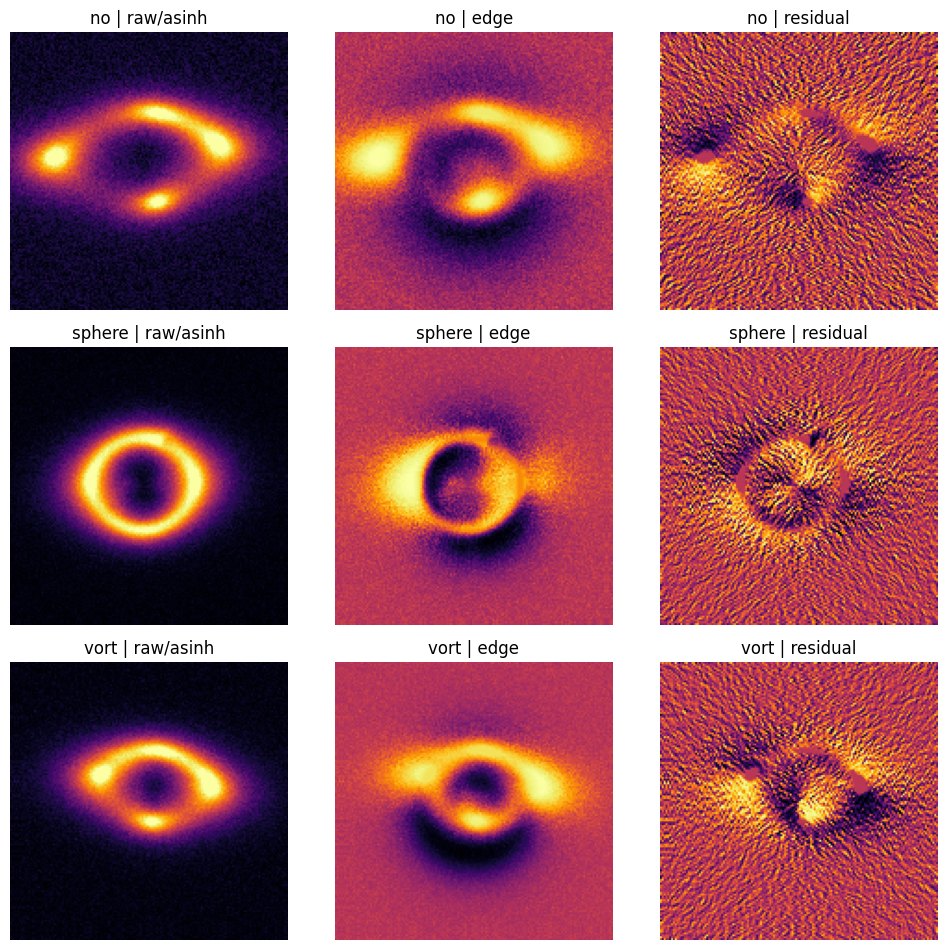

In [11]:

def show_physics_channels(dataset: Dataset, n_per_class: int = 1):
    class_to_indices = defaultdict(list)
    for i, row in dataset.df.iterrows():
        if len(class_to_indices[row.class_name]) < n_per_class:
            class_to_indices[row.class_name].append(i)

    n_rows = len(cfg.class_names)
    fig, axes = plt.subplots(n_rows, 3, figsize=(10, 3.2 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)

    for r, cls in enumerate(cfg.class_names):
        idx = class_to_indices[cls][0]
        x, _ = dataset[idx]
        x = x.numpy()
        if cfg.normalize_to_minus1_1:
            x = (x * 0.5) + 0.5
        titles = [f"{cls} | raw/asinh", f"{cls} | edge", f"{cls} | residual"]
        for c in range(3):
            axes[r, c].imshow(x[c], cmap="inferno")
            axes[r, c].set_title(titles[c])
            axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

show_physics_channels(train_ds, n_per_class=1)


In [12]:
def adapt_densenet_small_image_stem(model: nn.Module) -> nn.Module:
    if not (hasattr(model, "features") and hasattr(model.features, "conv0")):
        return model

    old_conv = model.features.conv0
    new_conv = nn.Conv2d(
        in_channels=old_conv.in_channels,
        out_channels=old_conv.out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )

    with torch.no_grad():
        if old_conv.weight.shape[-1] >= 3:
            center = old_conv.weight[:, :, 2:5, 2:5].clone()
            old_std = old_conv.weight.std().clamp_min(1e-6)
            center_std = center.std().clamp_min(1e-6)
            center = center * (old_std / center_std)
            new_conv.weight.copy_(center)
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")

    model.features.conv0 = new_conv
    return model


KX = torch.tensor([[0.0, 0.0, 0.0], [-0.5, 0.0, 0.5], [0.0, 0.0, 0.0]], dtype=torch.float32).view(1, 1, 3, 3)
KY = torch.tensor([[0.0, -0.5, 0.0], [0.0, 0.0, 0.0], [0.0, 0.5, 0.0]], dtype=torch.float32).view(1, 1, 3, 3)
KBLUR = torch.tensor(
    [[1.0, 2.0, 1.0], [2.0, 4.0, 2.0], [1.0, 2.0, 1.0]],
    dtype=torch.float32,
).view(1, 1, 3, 3) / 16.0


def _apply_depthwise_kernel(x: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
    kernel = kernel.to(device=x.device, dtype=x.dtype)
    kernel = kernel.repeat(x.shape[1], 1, 1, 1)
    return F.conv2d(x, kernel, padding=1, groups=x.shape[1])


def spatial_dx(x: torch.Tensor) -> torch.Tensor:
    return _apply_depthwise_kernel(x, KX)


def spatial_dy(x: torch.Tensor) -> torch.Tensor:
    return _apply_depthwise_kernel(x, KY)


def blur2d(x: torch.Tensor) -> torch.Tensor:
    return _apply_depthwise_kernel(x, KBLUR)


def total_variation(x: torch.Tensor) -> torch.Tensor:
    return (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().mean() + (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().mean()


class PhysicsGuidedDenseNetPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            cfg.model_name,
            pretrained=cfg.pretrained,
            in_chans=cfg.in_chans,
            num_classes=0,
            global_pool="",
        )

        if cfg.use_small_image_stem:
            self.backbone = adapt_densenet_small_image_stem(self.backbone)

        feat_dim = self.backbone.num_features
        phys_hidden = max(64, feat_dim // 4)

        self.physics_head = nn.Sequential(
            nn.Conv2d(feat_dim, phys_hidden, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(phys_hidden),
            nn.GELU(),
            nn.Conv2d(phys_hidden, phys_hidden // 2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(phys_hidden // 2),
            nn.GELU(),
            nn.Conv2d(phys_hidden // 2, 2, kernel_size=1),
        )

        phys_channels = 6
        self.main_head = nn.Sequential(
            nn.Linear(feat_dim * 2 + phys_channels * 2, 512),
            nn.GELU(),
            nn.Dropout(cfg.head_dropout),
            nn.Linear(512, len(cfg.class_names)),
        )
        self.aux_head = nn.Sequential(
            nn.Linear(phys_channels * 2, 128),
            nn.GELU(),
            nn.Dropout(cfg.aux_head_dropout),
            nn.Linear(128, len(cfg.class_names)),
        )

    def forward(self, x: torch.Tensor):
        feats = self.backbone.forward_features(x)
        if isinstance(feats, (list, tuple)):
            feats = feats[-1]

        phys_pred = self.physics_head(feats)
        phys_pred = F.interpolate(phys_pred, size=x.shape[-2:], mode="bilinear", align_corners=False)

        psi = phys_pred[:, 0:1]
        kappa_aux = phys_pred[:, 1:2]

        alpha_x = spatial_dx(psi)
        alpha_y = spatial_dy(psi)

        psi_xx = spatial_dx(alpha_x)
        psi_yy = spatial_dy(alpha_y)
        psi_xy = spatial_dy(alpha_x)

        kappa_from_psi = 0.5 * (psi_xx + psi_yy)
        shear1 = 0.5 * (psi_xx - psi_yy)
        shear2 = psi_xy

        alpha_mag = torch.sqrt(alpha_x.square() + alpha_y.square() + 1e-6)
        shear_mag = torch.sqrt(shear1.square() + shear2.square() + 1e-6)
        delta_kappa = kappa_from_psi - blur2d(kappa_from_psi)

        phys_maps = torch.cat(
            [psi, kappa_aux, kappa_from_psi, alpha_mag, shear_mag, delta_kappa],
            dim=1,
        )

        feat_pool = torch.cat(
            [
                F.adaptive_avg_pool2d(feats, 1).flatten(1),
                F.adaptive_max_pool2d(feats, 1).flatten(1),
            ],
            dim=1,
        )
        phys_pool = torch.cat(
            [
                F.adaptive_avg_pool2d(phys_maps, 1).flatten(1),
                F.adaptive_max_pool2d(phys_maps, 1).flatten(1),
            ],
            dim=1,
        )

        logits = self.main_head(torch.cat([feat_pool, phys_pool], dim=1))
        aux_logits = self.aux_head(phys_pool)

        return {
            "logits": logits,
            "aux_logits": aux_logits,
            "psi": psi,
            "kappa_aux": kappa_aux,
            "kappa_from_psi": kappa_from_psi,
            "alpha_x": alpha_x,
            "alpha_y": alpha_y,
        }


def build_model() -> nn.Module:
    return PhysicsGuidedDenseNetPINN()


def extract_logits(model_out):
    if isinstance(model_out, dict):
        logits = model_out["logits"]
        if "aux_logits" in model_out:
            logits = logits + cfg.infer_aux_weight * model_out["aux_logits"]
        return logits
    return model_out


def compute_physics_regularizer(model_out):
    if not isinstance(model_out, dict):
        z = torch.tensor(0.0, device=device)
        return z, {"phys_loss": 0.0}

    div_alpha = spatial_dx(model_out["alpha_x"]) + spatial_dy(model_out["alpha_y"])
    curl_alpha = spatial_dx(model_out["alpha_y"]) - spatial_dy(model_out["alpha_x"])

    loss_kappa = F.smooth_l1_loss(div_alpha, 2.0 * model_out["kappa_aux"])
    loss_curl = curl_alpha.abs().mean()
    loss_psi_tv = total_variation(model_out["psi"])
    loss_kappa_tv = total_variation(model_out["kappa_from_psi"])

    phys_loss = (
        cfg.kappa_consistency_weight * loss_kappa
        + cfg.curl_weight * loss_curl
        + cfg.psi_tv_weight * loss_psi_tv
        + cfg.kappa_tv_weight * loss_kappa_tv
    )

    return phys_loss, {
        "phys_loss": float(phys_loss.detach().cpu()),
        "loss_kappa": float(loss_kappa.detach().cpu()),
        "loss_curl": float(loss_curl.detach().cpu()),
    }


model = build_model()
n_params_m = sum(p.numel() for p in model.parameters()) / 1e6
print(f"{cfg.model_name} PINN params (M): {n_params_m:.2f}")
print(f"in_chans: {cfg.in_chans}")
print(f"use_small_image_stem: {cfg.use_small_image_stem}")
del model
gc.collect()


model.safetensors:   0%|          | 0.00/116M [00:00<?, ?B/s]

densenet161 PINN params (M): 41.08
in_chans: 4
use_small_image_stem: True


20673

In [13]:

def compute_auc_metrics(y_true: np.ndarray, y_prob: np.ndarray, class_names: tuple[str, ...]):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_prob.argmax(axis=1))),
        "macro_f1": float(f1_score(y_true, y_prob.argmax(axis=1), average="macro")),
        "macro_auc_ovr": float(
            roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
        ),
        "weighted_auc_ovr": float(
            roc_auc_score(y_true_bin, y_prob, average="weighted", multi_class="ovr")
        ),
    }

    per_class_auc = {}
    for i, cls in enumerate(class_names):
        per_class_auc[cls] = float(roc_auc_score(y_true_bin[:, i], y_prob[:, i]))

    return metrics, per_class_auc


def plot_multiclass_roc(y_true: np.ndarray, y_prob: np.ndarray, class_names: tuple[str, ...]):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} | AUC={auc_i:.5f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-Rest ROC curves")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, class_names: tuple[str, ...]):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.tight_layout()
    plt.show()


In [14]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, use_d4_tta: bool = False):
    model.eval()
    probs_all, labels_all = [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=(device.type == "cuda"))

        if not use_d4_tta:
            model_out = model(xb)
            logits = extract_logits(model_out)
            prob = torch.softmax(logits, dim=1)
        else:
            prob_sum = 0.0
            n_views = 0
            for k in range(4):
                xr = torch.rot90(xb, k=k, dims=(2, 3))
                model_out_r = model(xr)
                prob_sum = prob_sum + torch.softmax(extract_logits(model_out_r), dim=1)
                n_views += 1

                xf = torch.flip(xr, dims=(3,))
                model_out_f = model(xf)
                prob_sum = prob_sum + torch.softmax(extract_logits(model_out_f), dim=1)
                n_views += 1

            prob = prob_sum / n_views

        probs_all.append(prob.cpu().numpy())
        labels_all.append(yb.numpy())

    y_true = np.concatenate(labels_all)
    y_prob = np.concatenate(probs_all)
    return y_true, y_prob


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion=None, use_d4_tta: bool = False):
    model.eval()
    all_true, all_prob = [], []
    val_loss_sum = 0.0
    val_count = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=(device.type == "cuda"))
        yb = yb.to(device, non_blocking=(device.type == "cuda"))

        if not use_d4_tta:
            model_out = model(xb)
            logits = extract_logits(model_out)
            prob = torch.softmax(logits, dim=1)
        else:
            prob_sum = 0.0
            logits_sum = 0.0
            n_views = 0
            for k in range(4):
                xr = torch.rot90(xb, k=k, dims=(2, 3))
                out_r = model(xr)
                logits_r = extract_logits(out_r)
                prob_sum = prob_sum + torch.softmax(logits_r, dim=1)
                logits_sum = logits_sum + logits_r
                n_views += 1

                xf = torch.flip(xr, dims=(3,))
                out_f = model(xf)
                logits_f = extract_logits(out_f)
                prob_sum = prob_sum + torch.softmax(logits_f, dim=1)
                logits_sum = logits_sum + logits_f
                n_views += 1

            prob = prob_sum / n_views
            logits = logits_sum / n_views

        if criterion is not None:
            loss = criterion(logits, yb)
            val_loss_sum += loss.item() * xb.size(0)
            val_count += xb.size(0)

        all_true.append(yb.cpu().numpy())
        all_prob.append(prob.cpu().numpy())

    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)
    metrics, per_class_auc = compute_auc_metrics(y_true, y_prob, cfg.class_names)
    val_loss = val_loss_sum / max(1, val_count) if criterion is not None else np.nan
    return val_loss, y_true, y_prob, metrics, per_class_auc


In [15]:
def save_topk_checkpoint(topk_heap, metric_value, save_path, payload, k):
    metric_value = float(metric_value)
    heapq.heappush(topk_heap, (metric_value, str(save_path)))
    torch.save(payload, save_path)

    if len(topk_heap) > k:
        worst_metric, worst_path = heapq.heappop(topk_heap)
        if Path(worst_path).exists() and worst_path != str(save_path):
            Path(worst_path).unlink()


def train_one_run():
    model = build_model().to(device)
    ema = ModelEmaV2(model, decay=cfg.ema_decay) if cfg.use_ema else None

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    train_criterion = LabelSmoothingCrossEntropy(smoothing=cfg.label_smoothing)
    eval_criterion = nn.CrossEntropyLoss()
    scaler = GradScaler(enabled=cfg.use_amp and device.type == "cuda")

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=0.2,
        end_factor=1.0,
        total_iters=max(1, cfg.warmup_epochs),
    )
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, cfg.epochs - cfg.warmup_epochs),
        eta_min=cfg.min_lr,
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[cfg.warmup_epochs],
    )

    best_score = -np.inf
    best_epoch = -1
    best_state = None
    history = []
    patience_counter = 0
    topk_heap = []

    best_ckpt_path = RUN_ROOT / f"best_{cfg.model_name}_pinn.pth"
    last_ckpt_path = RUN_ROOT / f"last_{cfg.model_name}_pinn.pth"

    for epoch in range(cfg.epochs):
        model.train()
        running_loss = 0.0
        running_phys = 0.0
        n_seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=(device.type == "cuda"))
            yb = yb.to(device, non_blocking=(device.type == "cuda"))

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=cfg.use_amp and device.type == "cuda"):
                model_out = model(xb)
                logits = extract_logits(model_out)
                cls_loss = train_criterion(logits, yb)

                aux_loss = torch.tensor(0.0, device=xb.device)
                if isinstance(model_out, dict) and "aux_logits" in model_out:
                    aux_loss = train_criterion(model_out["aux_logits"], yb)

                phys_loss, phys_terms = compute_physics_regularizer(model_out)
                loss = cls_loss + cfg.aux_phys_cls_weight * aux_loss + phys_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update(model)

            running_loss += loss.item() * xb.size(0)
            running_phys += phys_terms["phys_loss"] * xb.size(0)
            n_seen += xb.size(0)

        scheduler.step()

        # Light validation pass only for model selection / top-k bookkeeping.
        # This is NOT the final inference notebook.
        eval_model = ema.module if ema is not None else model
        val_loss, y_true_val, y_prob_val, metrics, per_class_auc = evaluate_model(
            eval_model,
            val_loader,
            criterion=eval_criterion,
            use_d4_tta=False,
        )

        train_loss = running_loss / max(1, n_seen)
        train_phys = running_phys / max(1, n_seen)
        epoch_record = {
            "epoch": epoch + 1,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": float(train_loss),
            "train_phys_loss": float(train_phys),
            "val_loss": float(val_loss),
            **metrics,
            **{f"auc_{k}": float(v) for k, v in per_class_auc.items()},
        }
        history.append(epoch_record)

        score = float(metrics["macro_auc_ovr"])

        print(
            f"{cfg.model_name}-PINN | epoch {epoch+1}: "
            f"train_loss={train_loss:.4f} | "
            f"train_phys={train_phys:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={metrics['accuracy']:.4f} | "
            f"val_macro_f1={metrics['macro_f1']:.4f} | "
            f"val_macro_auc={metrics['macro_auc_ovr']:.4f}"
        )
        print("per-class AUC:", per_class_auc)

        ckpt_name = f"{cfg.model_name}_pinn_epoch{epoch+1:02d}_auc{score:.6f}.pth"
        ckpt_path = CKPT_ROOT / ckpt_name
        payload = {
            "model_state_dict": copy.deepcopy(eval_model.state_dict()),
            "cfg": asdict(cfg),
            "best_epoch": epoch + 1,
            "best_macro_auc_ovr": float(score),
            "architecture": "PhysicsGuidedDenseNetPINN",
        }

        save_topk_checkpoint(topk_heap, score, ckpt_path, payload, cfg.save_top_k)

        # Always save a stable 'last' checkpoint after each completed epoch.
        torch.save(payload, last_ckpt_path)

        history_df, topk_df, history_path, topk_path = save_training_tables(history, topk_heap)

        if score > best_score:
            best_score = score
            best_epoch = epoch + 1
            patience_counter = 0
            best_state = payload
            torch.save(best_state, best_ckpt_path)
            write_json(
                {
                    "best_epoch": int(best_epoch),
                    "best_macro_auc_ovr": float(best_score),
                    "best_checkpoint_path": str(best_ckpt_path),
                },
                RUN_ROOT / "best_snapshot.json",
            )
        else:
            patience_counter += 1

        manifest_path = save_artifact_manifest(
            best_epoch=best_epoch if best_epoch > 0 else None,
            best_score=best_score if np.isfinite(best_score) else None,
        )
        bundle_path = package_artifacts()

        # Sync only the artifacts needed to resume / do inference later in another notebook.
        sync_files_to_hf([
            cfg_path,
            SPLIT_ROOT / "train_split.csv",
            SPLIT_ROOT / "val_split.csv",
            SPLIT_ROOT / "full_dataset_index.csv",
            SPLIT_ROOT / "split_metadata.json",
            ckpt_path,
            last_ckpt_path,
            best_ckpt_path if best_ckpt_path.exists() else None,
            history_path,
            topk_path,
            RUN_ROOT / "best_snapshot.json",
            manifest_path,
            bundle_path,
        ])

        print(f"Saved epoch checkpoint : {ckpt_path}")
        print(f"Saved last checkpoint  : {last_ckpt_path}")
        if best_ckpt_path.exists():
            print(f"Saved best checkpoint  : {best_ckpt_path}")
        print(f"Saved history csv      : {history_path}")
        print(f"Saved top-k csv        : {topk_path}")
        print(f"Saved artifact bundle  : {bundle_path}")

        if patience_counter >= cfg.early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

    history_df, topk_df, history_path, topk_path = save_training_tables(history, topk_heap)
    manifest_path = save_artifact_manifest(
        best_epoch=best_epoch if best_epoch > 0 else None,
        best_score=best_score if np.isfinite(best_score) else None,
    )
    bundle_path = package_artifacts()

    sync_files_to_hf([
        history_path,
        topk_path,
        best_ckpt_path if best_ckpt_path.exists() else None,
        last_ckpt_path if last_ckpt_path.exists() else None,
        RUN_ROOT / "best_snapshot.json",
        manifest_path,
        bundle_path,
    ])

    print(f"\nBest epoch: {best_epoch}")
    print(f"Best macro OvR AUC: {best_score:.6f}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_state, history_df, topk_df

In [ ]:
best_state, history_df, topk_df = train_one_run()

print("Training finished.")
print("Best checkpoints table:")
display(topk_df.head(10))

print("Recent training history:")
display(history_df.tail())

In [ ]:
from IPython.display import FileLink, display
from pathlib import Path

best_ckpt = RUN_ROOT / f"best_{cfg.model_name}_pinn.pth"
last_ckpt = RUN_ROOT / f"last_{cfg.model_name}_pinn.pth"

for p in [
    best_ckpt,
    last_ckpt,
    RUN_ROOT / "training_history.csv",
    RUN_ROOT / "topk_checkpoints.csv",
    RUN_ROOT / "artifact_bundle.zip",
]:
    if Path(p).exists():
        display(FileLink(str(p)))

## Train-only persistence

This notebook is now **training-first**.

What gets saved **during every epoch** so a Kaggle timeout does not destroy the run:
- `last_<model>_pinn.pth`
- `best_<model>_pinn.pth`
- epoch-named top-k checkpoints in `checkpoints/`
- `training_history.csv`
- `topk_checkpoints.csv`
- `run_config.json`
- `splits/train_split.csv`
- `splits/val_split.csv`
- `splits/full_dataset_index.csv`
- `splits/split_metadata.json`
- `best_snapshot.json`
- `artifact_manifest.json`
- `artifact_bundle.zip`

Optional external sync:
- If Kaggle secrets `HF_TOKEN` and `HF_REPO_ID` are set, the notebook uploads the above files to Hugging Face after every epoch.

Deliberately **not** saved in this training notebook:
- confusion matrix
- classification report
- per-run final inference outputs
- D4 TTA / ensemble evaluation outputs

Those belong in a separate evaluation notebook loaded from the saved checkpoints and split files.


In [ ]:
print("RUN_ROOT:", RUN_ROOT)
print("output_dir exists      :", RUN_ROOT.exists())
print("checkpoints dir exists :", CKPT_ROOT.exists())
print("history csv exists     :", (RUN_ROOT / "training_history.csv").exists())
print("topk csv exists        :", (RUN_ROOT / "topk_checkpoints.csv").exists())
print("run config exists      :", (RUN_ROOT / "run_config.json").exists())
print("train split exists     :", (SPLIT_ROOT / "train_split.csv").exists())
print("val split exists       :", (SPLIT_ROOT / "val_split.csv").exists())
print("best checkpoint exists :", (RUN_ROOT / f"best_{cfg.model_name}_pinn.pth").exists())
print("last checkpoint exists :", (RUN_ROOT / f"last_{cfg.model_name}_pinn.pth").exists())
print("artifact bundle exists :", BUNDLE_PATH.exists())
if HF_ENABLE_SYNC:
    print(f"HF sync enabled for repo: {HF_REPO_ID} ({HF_REPO_TYPE})")
else:
    print("HF sync disabled. Set HF_TOKEN and HF_REPO_ID as Kaggle secrets to enable it.")


In [ ]:
from pathlib import Path
import os

ckpt_dir = Path("/kaggle/working/outputs/checkpoints")
print("checkpoint dir exists:", ckpt_dir.exists())
print("checkpoint dir:", ckpt_dir)

if ckpt_dir.exists():
    files = sorted(ckpt_dir.glob("*"))
    print(f"\nFound {len(files)} files:\n")
    for f in files:
        size_mb = f.stat().st_size / (1024**2)
        print(f"{f.name:70s}  {size_mb:8.2f} MB")
else:
    print("Checkpoint directory does not exist.")

In [16]:
def load_checkpoint_model(ckpt_path: str | Path) -> nn.Module:
    bundle = torch.load(ckpt_path, map_location=device)
    model = build_model().to(device)
    model.load_state_dict(bundle["model_state_dict"])
    model.eval()
    return model, bundle


@torch.no_grad()
def ensemble_predict_proba(ckpt_paths, loader: DataLoader, use_d4_tta: bool = True):
    prob_sum = None
    y_true_ref = None
    n_models = 0

    for ckpt_path in ckpt_paths:
        model, _ = load_checkpoint_model(ckpt_path)
        y_true, y_prob = predict_proba(model, loader, use_d4_tta=use_d4_tta)
        prob_sum = y_prob if prob_sum is None else (prob_sum + y_prob)
        y_true_ref = y_true
        n_models += 1
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return y_true_ref, prob_sum / max(1, n_models)


def summarize_predictions(tag: str, y_true: np.ndarray, y_prob: np.ndarray):
    y_pred = y_prob.argmax(axis=1)
    metrics, per_class_auc = compute_auc_metrics(y_true, y_prob, cfg.class_names)
    print("=" * 70)
    print(tag)
    print(json.dumps(metrics, indent=2))
    print("per-class AUC:")
    print(json.dumps(per_class_auc, indent=2))
    print(classification_report(y_true, y_pred, target_names=cfg.class_names, digits=5))
    plot_multiclass_roc(y_true, y_prob, cfg.class_names)
    plot_confusion_matrix(y_true, y_pred, cfg.class_names)
    return metrics, per_class_auc, y_pred


In [17]:

def plot_history(history_df: pd.DataFrame):
    display(history_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{cfg.model_name} loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["macro_auc_ovr"], label="val_macro_auc")
    axes[1].plot(history_df["epoch"], history_df["accuracy"], label="val_acc")
    axes[1].plot(history_df["epoch"], history_df["macro_f1"], label="val_macro_f1")
    axes[1].set_title(f"{cfg.model_name} metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# plot_history(history_df)


# **Using weights saved in Hugging Face**

In [18]:
from pathlib import Path
import os
from huggingface_hub import snapshot_download

# -----------------------------
# HF repo settings
# -----------------------------
HF_REPO_ID = "Arushhh/deeplense-specific-test7-artifacts"
HF_REPO_TYPE = "dataset"

# optional private-token support
try:
    from kaggle_secrets import UserSecretsClient
    _sec = UserSecretsClient()
    HF_TOKEN = _sec.get_secret("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN", None)

# -----------------------------
# download artifact repo locally
# -----------------------------
HF_LOCAL_ROOT = Path("/kaggle/working/hf_artifacts")
HF_LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type=HF_REPO_TYPE,
    token=HF_TOKEN,
    local_dir=str(HF_LOCAL_ROOT),
    local_dir_use_symlinks=False,
    allow_patterns=["outputs_pinn/**"],
    ignore_patterns=["**/artifact_bundle.zip"],   # skip large zip; not needed for eval
)

ARTIFACT_ROOT = HF_LOCAL_ROOT / "outputs_pinn"
ARTIFACT_CKPT_DIR = ARTIFACT_ROOT / "checkpoints"
ARTIFACT_SPLIT_DIR = ARTIFACT_ROOT / "splits"

EVAL_OUTPUT_DIR = Path("/kaggle/working/final_eval_outputs")
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# important for eval-only mode
cfg.pretrained = False
cfg.use_amp = False
cfg.output_dir = str(EVAL_OUTPUT_DIR)
cfg.ckpt_dir = str(ARTIFACT_CKPT_DIR)
cfg.split_csv_dir = str(ARTIFACT_SPLIT_DIR)

print("ARTIFACT_ROOT      =", ARTIFACT_ROOT)
print("ARTIFACT_CKPT_DIR  =", ARTIFACT_CKPT_DIR)
print("ARTIFACT_SPLIT_DIR =", ARTIFACT_SPLIT_DIR)
print("EVAL_OUTPUT_DIR    =", EVAL_OUTPUT_DIR)

Fetching 45 files:   0%|          | 0/45 [00:00<?, ?it/s]

ARTIFACT_ROOT      = /kaggle/working/hf_artifacts/outputs_pinn
ARTIFACT_CKPT_DIR  = /kaggle/working/hf_artifacts/outputs_pinn/checkpoints
ARTIFACT_SPLIT_DIR = /kaggle/working/hf_artifacts/outputs_pinn/splits
EVAL_OUTPUT_DIR    = /kaggle/working/final_eval_outputs


In [19]:
from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import DataLoader

history_df = pd.read_csv(ARTIFACT_ROOT / "training_history.csv")
val_df = pd.read_csv(ARTIFACT_SPLIT_DIR / "val_split.csv")

# set this manually if autodetection fails
# cfg.data_root = "/kaggle/input/common-task-dataset/dataset"

DATASET_ROOT = find_dataset_root(cfg.data_root)
print("DATASET_ROOT:", DATASET_ROOT)

def remap_to_current_dataset(p):
    p = Path(str(p))
    if p.exists():
        return str(p)

    s = str(p).replace("\\", "/")

    # old absolute path contains /dataset/
    if "/dataset/" in s:
        rel = s.split("/dataset/", 1)[1]
        cand = DATASET_ROOT / rel
        if cand.exists():
            return str(cand)

    # fallback: locate from train/... or val/...
    parts = p.parts
    for split_name in ("train", "val"):
        if split_name in parts:
            idx = parts.index(split_name)
            cand = DATASET_ROOT.joinpath(*parts[idx:])
            if cand.exists():
                return str(cand)

    raise FileNotFoundError(f"Could not resolve dataset path: {p}")

val_df["path"] = val_df["path"].apply(remap_to_current_dataset)

missing_mask = ~val_df["path"].apply(lambda x: Path(x).exists())
print("Missing validation files:", int(missing_mask.sum()))
assert missing_mask.sum() == 0, "Some validation image paths are still missing."

# eval-only loader
val_ds = LensPhysicsDataset(val_df, train=False)
val_loader = DataLoader(
    val_ds,
    batch_size=min(cfg.batch_size, 16),
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=False,
)

print("Validation samples:", len(val_ds))
print("Validation batches:", len(val_loader))
display(val_df.head())

DATASET_ROOT: /kaggle/input/datasets/adityaaru/dataset-vii/dataset
Missing validation files: 0
Validation samples: 3750
Validation batches: 469


,path,label,class_name,source_split,sample_id
0,/kaggle/input/datasets/adityaaru/dataset-vii/d...,2,vort,provided_train,/kaggle/input/datasets/adityaaru/dataset-vii/d...
1,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train,/kaggle/input/datasets/adityaaru/dataset-vii/d...
2,/kaggle/input/datasets/adityaaru/dataset-vii/d...,1,sphere,provided_train,/kaggle/input/datasets/adityaaru/dataset-vii/d...
3,/kaggle/input/datasets/adityaaru/dataset-vii/d...,1,sphere,provided_train,/kaggle/input/datasets/adityaaru/dataset-vii/d...
4,/kaggle/input/datasets/adityaaru/dataset-vii/d...,2,vort,provided_train,/kaggle/input/datasets/adityaaru/dataset-vii/d...


In [20]:
import json
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

def remap_artifact_ckpt_path(p):
    p = Path(str(p))
    candidates = [
        p,
        ARTIFACT_CKPT_DIR / p.name,
        ARTIFACT_ROOT / p.name,
    ]
    for cand in candidates:
        if cand.exists():
            return str(cand)
    raise FileNotFoundError(f"Checkpoint not found for: {p}")

def save_history_plot(history_df: pd.DataFrame, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title("Loss curves")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    if "train_phys_loss" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["train_phys_loss"], label="train_phys_loss")
        axes[1].set_title("Physics loss")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()
    else:
        axes[1].axis("off")

    axes[2].plot(history_df["epoch"], history_df["macro_auc_ovr"], label="macro_auc_ovr")
    axes[2].plot(history_df["epoch"], history_df["accuracy"], label="accuracy")
    axes[2].plot(history_df["epoch"], history_df["macro_f1"], label="macro_f1")
    axes[2].set_title("Validation metrics")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    fig.savefig(out_dir / "training_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

def save_multiclass_roc(y_true: np.ndarray, y_prob: np.ndarray, class_names, out_path: Path, title: str):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} | AUC={auc_i:.5f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

def save_confusion_matrix_plot(y_true: np.ndarray, y_pred: np.ndarray, class_names, out_path: Path, title: str):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    return cm

def save_eval_outputs(
    tag: str,
    y_true: np.ndarray,
    y_prob: np.ndarray,
    val_df: pd.DataFrame,
    out_dir: Path,
):
    out_dir.mkdir(parents=True, exist_ok=True)

    y_pred = y_prob.argmax(axis=1)
    metrics, per_class_auc = compute_auc_metrics(y_true, y_prob, cfg.class_names)

    report_txt = classification_report(
        y_true,
        y_pred,
        target_names=cfg.class_names,
        digits=5,
    )

    pred_df = pd.DataFrame({
        "path": val_df["path"].values,
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_no": y_prob[:, 0],
        "prob_sphere": y_prob[:, 1],
        "prob_vort": y_prob[:, 2],
    })
    pred_df.to_csv(out_dir / f"val_predictions_{tag}.csv", index=False)

    cm = save_confusion_matrix_plot(
        y_true, y_pred, cfg.class_names,
        out_dir / f"confusion_matrix_{tag}.png",
        f"Confusion Matrix: {tag}"
    )

    save_multiclass_roc(
        y_true, y_prob, cfg.class_names,
        out_dir / f"roc_{tag}.png",
        f"ROC Curves: {tag}"
    )

    with open(out_dir / f"classification_report_{tag}.txt", "w") as f:
        f.write(report_txt)

    with open(out_dir / f"metrics_{tag}.json", "w") as f:
        json.dump({
            "tag": tag,
            "metrics": metrics,
            "per_class_auc": per_class_auc,
            "confusion_matrix": cm.tolist(),
        }, f, indent=2)

    print("=" * 80)
    print(tag)
    print(json.dumps(metrics, indent=2))
    print("per-class AUC:")
    print(json.dumps(per_class_auc, indent=2))
    print(report_txt)

    return metrics, per_class_auc, y_pred

,epoch,lr,train_loss,train_phys_loss,val_loss,accuracy,macro_f1,macro_auc_ovr,weighted_auc_ovr,auc_no,auc_sphere,auc_vort
29,30,0.000016,0.279171,0.000142,0.115746,0.969067,0.969042,0.996112,0.996112,0.996512,0.994168,0.997655
30,31,0.000010,0.271718,0.000135,0.106608,0.972267,0.972257,0.996406,0.996406,0.996538,0.994430,0.998250
31,32,0.000006,0.271950,0.000134,0.105552,0.972000,0.971981,0.996531,0.996531,0.996568,0.994511,0.998514
32,33,0.000003,0.261422,0.000135,0.106269,0.972533,0.972508,0.996464,0.996464,0.996594,0.994396,0.998403
33,34,0.000002,0.270834,0.000131,0.105853,0.971467,0.971445,0.996552,0.996552,0.996662,0.994562,0.998433


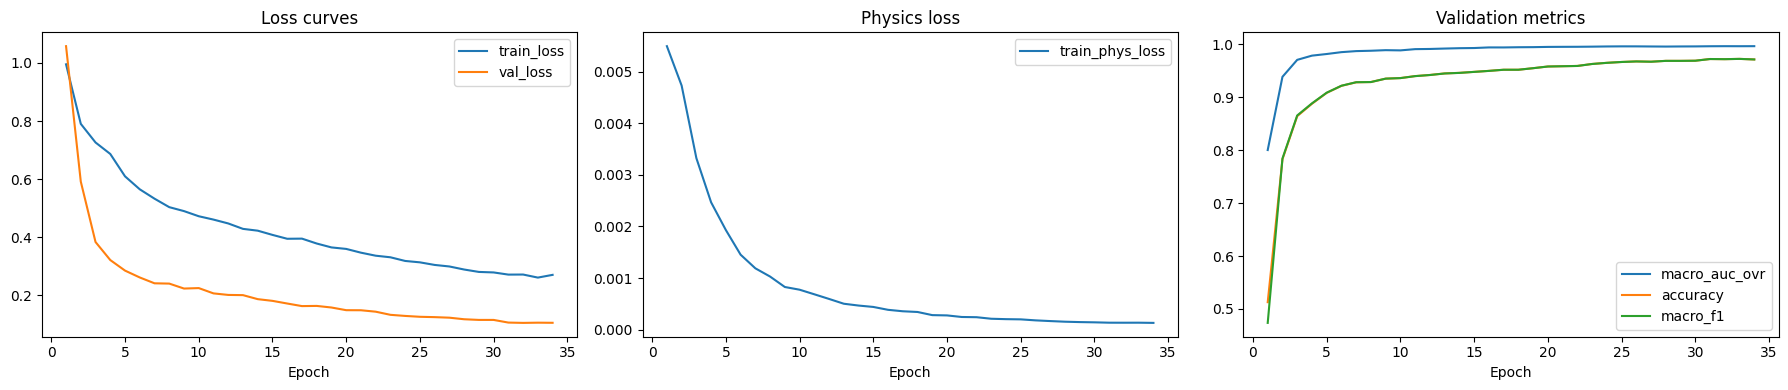

In [21]:
history_df = pd.read_csv(ARTIFACT_ROOT / "training_history.csv")
display(history_df.tail())

save_history_plot(history_df, EVAL_OUTPUT_DIR)
history_df.to_csv(EVAL_OUTPUT_DIR / "training_history_eval_copy.csv", index=False)

Best checkpoint: /kaggle/working/hf_artifacts/outputs_pinn/best_densenet161_pinn.pth
Top-k checkpoints used:


,macro_auc_ovr,checkpoint_path
0,0.996552,/kaggle/working/hf_artifacts/outputs_pinn/chec...
1,0.996531,/kaggle/working/hf_artifacts/outputs_pinn/chec...
2,0.996464,/kaggle/working/hf_artifacts/outputs_pinn/chec...
3,0.996406,/kaggle/working/hf_artifacts/outputs_pinn/chec...
4,0.996198,/kaggle/working/hf_artifacts/outputs_pinn/chec...


Final setting comparison:


,setting,accuracy,macro_f1,macro_auc_ovr,weighted_auc_ovr
0,best_ckpt_no_tta,0.971467,0.971445,0.996552,0.996552
1,top5_ckpt_d4_tta_ensemble,0.969867,0.969841,0.996437,0.996437
2,best_ckpt_d4_tta,0.971467,0.971417,0.996423,0.996423


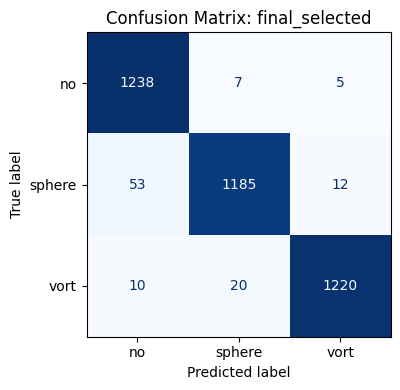

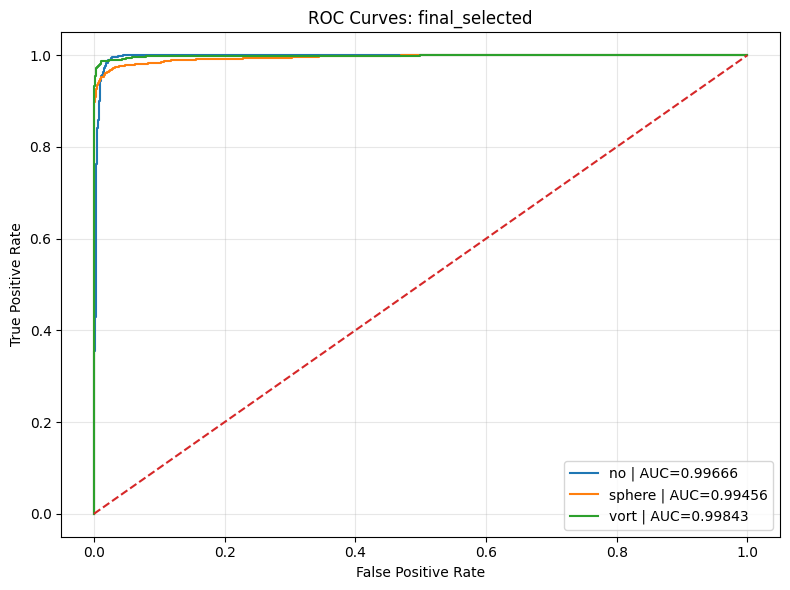

final_selected
{
  "accuracy": 0.9714666666666667,
  "macro_f1": 0.9714445000958839,
  "macro_auc_ovr": 0.9965523199999998,
  "weighted_auc_ovr": 0.9965523199999998
}
per-class AUC:
{
  "no": 0.99666208,
  "sphere": 0.9945622399999998,
  "vort": 0.99843264
}
              precision    recall  f1-score   support

          no    0.95158   0.99040   0.97060      1250
      sphere    0.97772   0.94800   0.96263      1250
        vort    0.98626   0.97600   0.98110      1250

    accuracy                        0.97147      3750
   macro avg    0.97185   0.97147   0.97144      3750
weighted avg    0.97185   0.97147   0.97144      3750



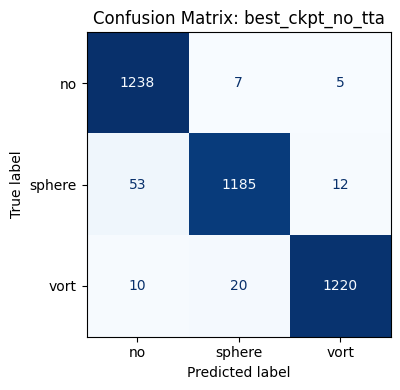

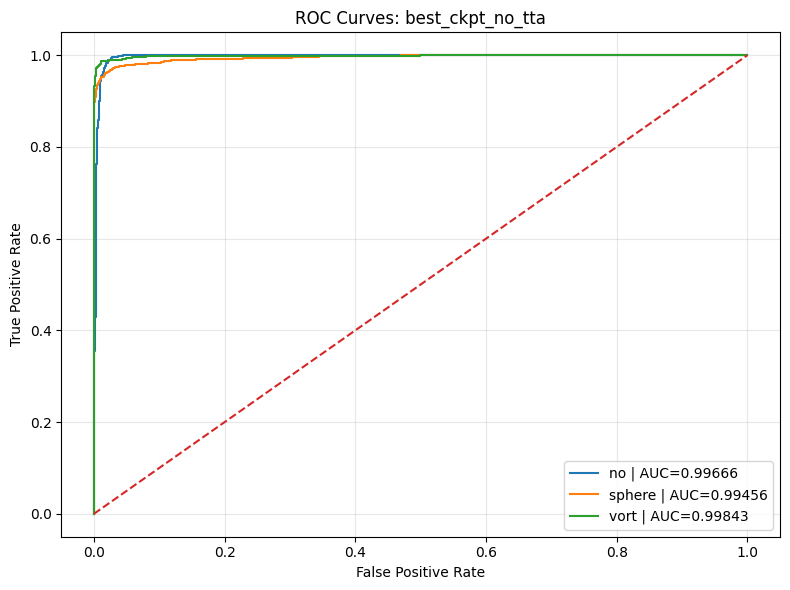

best_ckpt_no_tta
{
  "accuracy": 0.9714666666666667,
  "macro_f1": 0.9714445000958839,
  "macro_auc_ovr": 0.9965523199999998,
  "weighted_auc_ovr": 0.9965523199999998
}
per-class AUC:
{
  "no": 0.99666208,
  "sphere": 0.9945622399999998,
  "vort": 0.99843264
}
              precision    recall  f1-score   support

          no    0.95158   0.99040   0.97060      1250
      sphere    0.97772   0.94800   0.96263      1250
        vort    0.98626   0.97600   0.98110      1250

    accuracy                        0.97147      3750
   macro avg    0.97185   0.97147   0.97144      3750
weighted avg    0.97185   0.97147   0.97144      3750



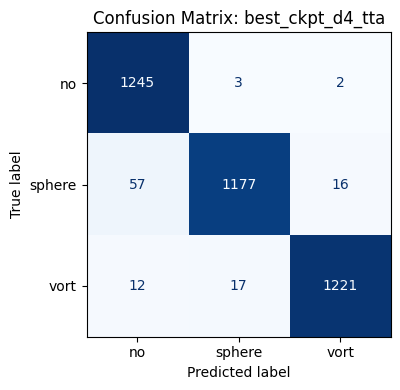

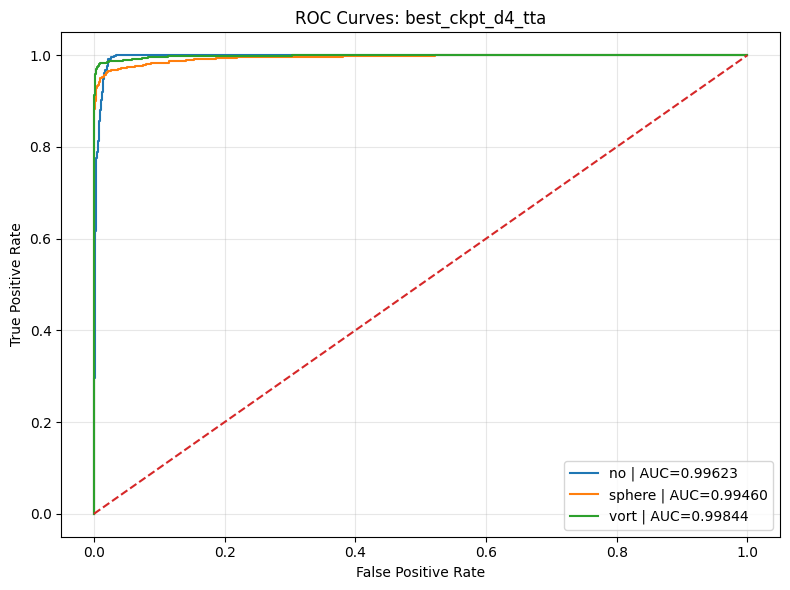

best_ckpt_d4_tta
{
  "accuracy": 0.9714666666666667,
  "macro_f1": 0.9714166795619694,
  "macro_auc_ovr": 0.9964232533333334,
  "weighted_auc_ovr": 0.9964232533333334
}
per-class AUC:
{
  "no": 0.9962297600000001,
  "sphere": 0.99460192,
  "vort": 0.99843808
}
              precision    recall  f1-score   support

          no    0.94749   0.99600   0.97114      1250
      sphere    0.98329   0.94160   0.96199      1250
        vort    0.98547   0.97680   0.98112      1250

    accuracy                        0.97147      3750
   macro avg    0.97208   0.97147   0.97142      3750
weighted avg    0.97208   0.97147   0.97142      3750



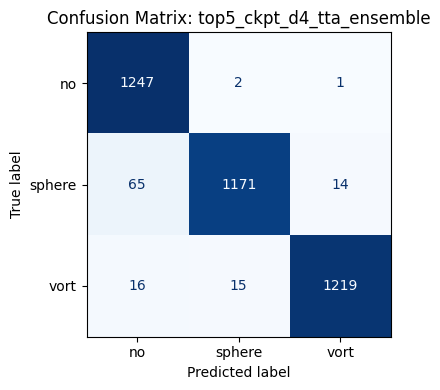

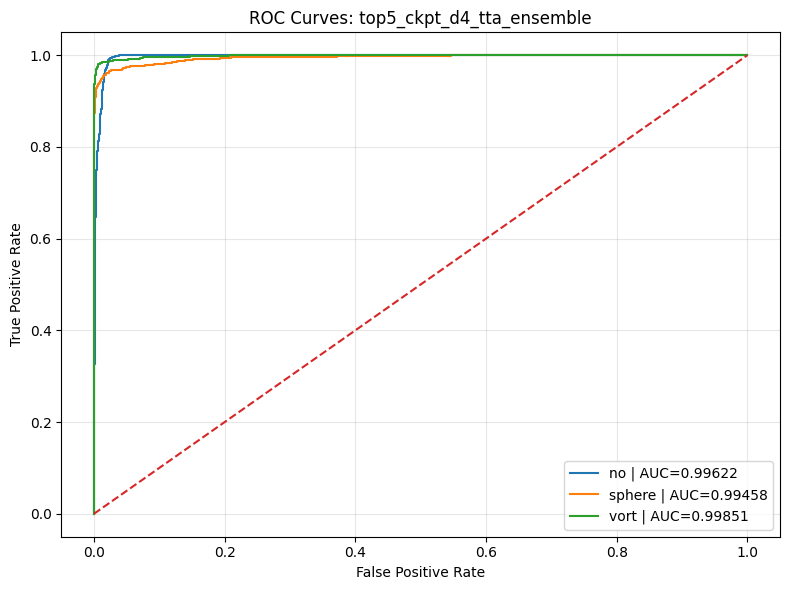

top5_ckpt_d4_tta_ensemble
{
  "accuracy": 0.9698666666666667,
  "macro_f1": 0.9698405151175091,
  "macro_auc_ovr": 0.9964369066666666,
  "weighted_auc_ovr": 0.9964369066666666
}
per-class AUC:
{
  "no": 0.99621536,
  "sphere": 0.9945820799999999,
  "vort": 0.99851328
}
              precision    recall  f1-score   support

          no    0.93901   0.99760   0.96742      1250
      sphere    0.98569   0.93680   0.96062      1250
        vort    0.98784   0.97520   0.98148      1250

    accuracy                        0.96987      3750
   macro avg    0.97085   0.96987   0.96984      3750
weighted avg    0.97085   0.96987   0.96984      3750


Selected final setting: best_ckpt_no_tta
Final metrics saved to: /kaggle/working/final_eval_outputs/final_metrics.json
Outputs folder: /kaggle/working/final_eval_outputs


In [22]:
import torch
import torch.nn as nn
import pandas as pd
import json
from pathlib import Path

# -----------------------------
# locate checkpoints from artifacts
# -----------------------------
best_ckpt_candidates = sorted(ARTIFACT_ROOT.glob("best_*_pinn.pth"))
assert len(best_ckpt_candidates) > 0, "No best_*_pinn.pth found in artifact root"
best_ckpt_path = best_ckpt_candidates[0]

topk_csv_path = ARTIFACT_ROOT / "topk_checkpoints.csv"
assert topk_csv_path.exists(), "topk_checkpoints.csv not found"

topk_df = pd.read_csv(topk_csv_path)
topk_df["checkpoint_path"] = topk_df["checkpoint_path"].apply(remap_artifact_ckpt_path)
topk_df = topk_df.sort_values("macro_auc_ovr", ascending=False).reset_index(drop=True)

ckpt_paths = topk_df["checkpoint_path"].tolist()[: cfg.final_eval_top_k]
print("Best checkpoint:", best_ckpt_path)
print("Top-k checkpoints used:")
display(topk_df.head(cfg.final_eval_top_k))

# -----------------------------
# evaluate single best checkpoint
# -----------------------------
best_model, best_bundle = load_checkpoint_model(best_ckpt_path)
ce_criterion = nn.CrossEntropyLoss()

# 1) best checkpoint, no TTA
val_loss_plain, y_true_plain, y_prob_plain, metrics_plain, per_class_auc_plain = evaluate_model(
    best_model,
    val_loader,
    criterion=ce_criterion,
    use_d4_tta=False,
)

# 2) best checkpoint, D4 TTA
_, y_true_tta, y_prob_tta, metrics_tta, per_class_auc_tta = evaluate_model(
    best_model,
    val_loader,
    criterion=None,
    use_d4_tta=True,
)

del best_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 3) top-k checkpoint ensemble, D4 TTA
y_true_ens, y_prob_ens = ensemble_predict_proba(
    ckpt_paths,
    val_loader,
    use_d4_tta=True,
)
metrics_ens, per_class_auc_ens = compute_auc_metrics(y_true_ens, y_prob_ens, cfg.class_names)

# -----------------------------
# compare settings
# -----------------------------
summary_rows = [
    {"setting": "best_ckpt_no_tta", **metrics_plain},
    {"setting": "best_ckpt_d4_tta", **metrics_tta},
    {"setting": f"top{len(ckpt_paths)}_ckpt_d4_tta_ensemble", **metrics_ens},
]
summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("macro_auc_ovr", ascending=False)
    .reset_index(drop=True)
)

print("Final setting comparison:")
display(summary_df)
summary_df.to_csv(EVAL_OUTPUT_DIR / "setting_comparison.csv", index=False)

best_setting = summary_df.iloc[0]["setting"]

if best_setting == "best_ckpt_no_tta":
    final_y_true, final_y_prob = y_true_plain, y_prob_plain
elif best_setting == "best_ckpt_d4_tta":
    final_y_true, final_y_prob = y_true_tta, y_prob_tta
else:
    final_y_true, final_y_prob = y_true_ens, y_prob_ens

final_metrics, final_per_class_auc, final_y_pred = save_eval_outputs(
    tag="final_selected",
    y_true=final_y_true,
    y_prob=final_y_prob,
    val_df=val_df,
    out_dir=EVAL_OUTPUT_DIR,
)

# save the other two settings as well
save_eval_outputs(
    tag="best_ckpt_no_tta",
    y_true=y_true_plain,
    y_prob=y_prob_plain,
    val_df=val_df,
    out_dir=EVAL_OUTPUT_DIR,
)

save_eval_outputs(
    tag="best_ckpt_d4_tta",
    y_true=y_true_tta,
    y_prob=y_prob_tta,
    val_df=val_df,
    out_dir=EVAL_OUTPUT_DIR,
)

save_eval_outputs(
    tag=f"top{len(ckpt_paths)}_ckpt_d4_tta_ensemble",
    y_true=y_true_ens,
    y_prob=y_prob_ens,
    val_df=val_df,
    out_dir=EVAL_OUTPUT_DIR,
)

final_payload = {
    "model_name": cfg.model_name,
    "best_epoch_from_best_checkpoint": int(best_bundle.get("best_epoch", -1)),
    "selected_setting": best_setting,
    "summary_table": summary_df.to_dict(orient="records"),
    "final_metrics": final_metrics,
    "final_per_class_auc": final_per_class_auc,
    "checkpoint_paths_used_for_ensemble": ckpt_paths,
    "tta": {
        "type": "D4",
        "views": 8,
        "details": "4 rotations + horizontal flip of each rotation"
    },
    "notes": {
        "validation_split_source": str(ARTIFACT_SPLIT_DIR / "val_split.csv"),
        "history_source": str(ARTIFACT_ROOT / "training_history.csv"),
        "topk_source": str(topk_csv_path),
    },
}
with open(EVAL_OUTPUT_DIR / "final_metrics.json", "w") as f:
    json.dump(final_payload, f, indent=2)

print("\nSelected final setting:", best_setting)
print("Final metrics saved to:", EVAL_OUTPUT_DIR / "final_metrics.json")
print("Outputs folder:", EVAL_OUTPUT_DIR)

In [23]:
from pathlib import Path
from IPython.display import FileLink, display

for p in sorted(EVAL_OUTPUT_DIR.glob("*")):
    if p.is_file():
        print(p.name)
        display(FileLink(str(p)))

classification_report_best_ckpt_d4_tta.txt


/kaggle/working/final_eval_outputs/classification_report_best_ckpt_d4_tta.txt

classification_report_best_ckpt_no_tta.txt


/kaggle/working/final_eval_outputs/classification_report_best_ckpt_no_tta.txt

classification_report_final_selected.txt


...

/kaggle/working/final_eval_outputs/val_predictions_best_ckpt_no_tta.csv

val_predictions_final_selected.csv


/kaggle/working/final_eval_outputs/val_predictions_final_selected.csv

val_predictions_top5_ckpt_d4_tta_ensemble.csv


/kaggle/working/final_eval_outputs/val_predictions_top5_ckpt_d4_tta_ensemble.csv

## Final inference is intentionally moved out of this training notebook

This notebook should stop after checkpoint persistence.

Use a second notebook for:
- loading `best_<model>_pinn.pth` or top-k checkpoints
- rebuilding `val_loader` from `splits/val_split.csv`
- running D4 TTA / ensemble inference
- saving confusion matrix, ROC curves, classification report, and final submission metrics

That separation is intentional so a Kaggle 12-hour timeout cannot wipe your training artifacts before final evaluation is run.


# If model_weights are present in input


In [ ]:
from pathlib import Path
import os

# -----------------------------
# Find attached artifact root automatically
# -----------------------------
best_ckpt_candidates = sorted(Path("/kaggle/input").rglob("best_*_pinn.pth"))
assert len(best_ckpt_candidates) > 0, "Could not find best_*_pinn.pth in /kaggle/input"

ARTIFACT_ROOT = best_ckpt_candidates[0].parent
ARTIFACT_CKPT_DIR = ARTIFACT_ROOT / "checkpoints"
ARTIFACT_SPLIT_DIR = ARTIFACT_ROOT / "splits"

# writable output dir for this eval-only session
EVAL_OUTPUT_DIR = Path("/kaggle/working/final_eval_outputs")
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ARTIFACT_ROOT      =", ARTIFACT_ROOT)
print("ARTIFACT_CKPT_DIR  =", ARTIFACT_CKPT_DIR)
print("ARTIFACT_SPLIT_DIR =", ARTIFACT_SPLIT_DIR)
print("EVAL_OUTPUT_DIR    =", EVAL_OUTPUT_DIR)

# Use the saved split from the attached artifacts
cfg.split_csv_dir = str(ARTIFACT_SPLIT_DIR)

# Save new eval outputs here
cfg.output_dir = str(EVAL_OUTPUT_DIR)

# This is only for reference in eval mode
if hasattr(cfg, "ckpt_dir"):
    cfg.ckpt_dir = str(ARTIFACT_CKPT_DIR)


In [ ]:
from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import DataLoader

# --------------------------------------------------
# Force evaluation to use the SAVED validation split
# from attached artifacts, and rebuild val_loader
# in single-process mode to avoid worker crashes
# --------------------------------------------------

history_df = pd.read_csv(ARTIFACT_ROOT / "training_history.csv")
val_df = pd.read_csv(ARTIFACT_SPLIT_DIR / "val_split.csv")

DATASET_ROOT = find_dataset_root(cfg.data_root)
print("DATASET_ROOT:", DATASET_ROOT)

def remap_to_current_dataset(p):
    p = Path(str(p))
    if p.exists():
        return str(p)

    s = str(p).replace("\\", "/")

    # Case 1: old absolute path contains /dataset/
    if "/dataset/" in s:
        rel = s.split("/dataset/", 1)[1]
        cand = DATASET_ROOT / rel
        if cand.exists():
            return str(cand)

    # Case 2: path contains train/... or val/... somewhere
    parts = p.parts
    for split_name in ("train", "val"):
        if split_name in parts:
            idx = parts.index(split_name)
            cand = DATASET_ROOT.joinpath(*parts[idx:])
            if cand.exists():
                return str(cand)

    raise FileNotFoundError(f"Could not resolve dataset path: {p}")

val_df["path"] = val_df["path"].apply(remap_to_current_dataset)

missing_mask = ~val_df["path"].apply(lambda x: Path(x).exists())
print("Missing validation files:", int(missing_mask.sum()))
assert missing_mask.sum() == 0, "Some validation image paths are still missing."

# Rebuild validation dataset/loader safely for eval-only session
val_ds = LensPhysicsDataset(val_df, train=False)
val_loader = DataLoader(
    val_ds,
    batch_size=min(cfg.batch_size, 16),   # keep reasonable for eval
    shuffle=False,
    num_workers=0,                        # IMPORTANT: avoid worker crashes
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=False,
)

print("Rebuilt val_loader safely.")
print("Validation samples:", len(val_ds))
print("Validation batches:", len(val_loader))
print(val_df.head())

## Final inference is intentionally moved out of this training notebook

This notebook should stop after checkpoint persistence.

Use a second notebook for:
- loading `best_<model>_pinn.pth` or top-k checkpoints
- rebuilding `val_loader` from `splits/val_split.csv`
- running D4 TTA / ensemble inference
- saving confusion matrix, ROC curves, classification report, and final submission metrics

That separation is intentional so a Kaggle 12-hour timeout cannot wipe your training artifacts before final evaluation is run.


## Final inference is intentionally moved out of this training notebook

This notebook should stop after checkpoint persistence.

Use a second notebook for:
- loading `best_<model>_pinn.pth` or top-k checkpoints
- rebuilding `val_loader` from `splits/val_split.csv`
- running D4 TTA / ensemble inference
- saving confusion matrix, ROC curves, classification report, and final submission metrics

That separation is intentional so a Kaggle 12-hour timeout cannot wipe your training artifacts before final evaluation is run.


In [ ]:
# # Final evaluation after training
# best_ckpt_path = Path(cfg.output_dir) / f"best_{cfg.model_name}_physics_3ch.pth"
# topk_csv_path = Path(cfg.output_dir) / "topk_checkpoints.csv"

# best_model, best_bundle = load_checkpoint_model(best_ckpt_path)
# ce_criterion = nn.CrossEntropyLoss()

# # 1) single best checkpoint, no TTA
# val_loss_plain, y_true_plain, y_prob_plain, metrics_plain, per_class_auc_plain = evaluate_model(
#     best_model,
#     val_loader,
#     criterion=ce_criterion,
#     use_d4_tta=False,
# )
# print(
#     f"{cfg.model_name} | epoch {int(best_bundle['best_epoch'])}: "
#     f"train_loss=see history_df | val_loss={val_loss_plain:.4f} | "
#     f"val_acc={metrics_plain['accuracy']:.4f} | "
#     f"val_macro_f1={metrics_plain['macro_f1']:.4f} | "
#     f"val_macro_auc={metrics_plain['macro_auc_ovr']:.4f}"
# )
# print("per-class AUC:", per_class_auc_plain)

# # 2) single best checkpoint, D4 TTA
# _, y_true_tta, y_prob_tta, metrics_tta, per_class_auc_tta = evaluate_model(
#     best_model,
#     val_loader,
#     criterion=None,
#     use_d4_tta=cfg.use_d4_tta,
# )

# # 3) top-k checkpoint ensemble with D4 TTA
# if topk_csv_path.exists():
#     topk_df = pd.read_csv(topk_csv_path)
#     ckpt_paths = (
#         topk_df.sort_values("macro_auc_ovr", ascending=False)["checkpoint_path"]
#         .tolist()[: cfg.final_eval_top_k]
#     )
# else:
#     ckpt_paths = [str(best_ckpt_path)]

# y_true_ens, y_prob_ens = ensemble_predict_proba(
#     ckpt_paths,
#     val_loader,
#     use_d4_tta=cfg.use_d4_tta,
# )
# metrics_ens, per_class_auc_ens = compute_auc_metrics(y_true_ens, y_prob_ens, cfg.class_names)

# del best_model
# gc.collect()
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

# summary_rows = [
#     {"setting": "best_ckpt_no_tta", **metrics_plain},
#     {"setting": "best_ckpt_d4_tta", **metrics_tta},
#     {"setting": f"top{len(ckpt_paths)}_ckpt_d4_tta_ensemble", **metrics_ens},
# ]
# summary_df = (
#     pd.DataFrame(summary_rows)
#     .sort_values("macro_auc_ovr", ascending=False)
#     .reset_index(drop=True)
# )
# print("Final setting comparison:")
# display(summary_df)

# best_setting = summary_df.iloc[0]["setting"]
# if best_setting == "best_ckpt_no_tta":
#     final_y_true, final_y_prob = y_true_plain, y_prob_plain
# elif best_setting == "best_ckpt_d4_tta":
#     final_y_true, final_y_prob = y_true_tta, y_prob_tta
# else:
#     final_y_true, final_y_prob = y_true_ens, y_prob_ens

# final_metrics, final_per_class_auc, final_y_pred = summarize_predictions(
#     best_setting,
#     final_y_true,
#     final_y_prob,
# )

# final_payload = {
#     "model_name": cfg.model_name,
#     "best_epoch": int(best_bundle["best_epoch"]),
#     "selected_setting": best_setting,
#     "summary_table": summary_df.to_dict(orient="records"),
#     "final_metrics": final_metrics,
#     "final_per_class_auc": final_per_class_auc,
#     "checkpoint_paths_used": ckpt_paths,
#     "notes": {
#         "small_image_stem": cfg.use_small_image_stem,
#         "global_pool": cfg.global_pool,
#         "use_d4_tta": cfg.use_d4_tta,
#         "final_eval_top_k": cfg.final_eval_top_k,
#     },
# }
# with open(Path(cfg.output_dir) / "final_metrics.json", "w") as f:
#     json.dump(final_payload, f, indent=2)

# pred_df = pd.DataFrame({
#     "path": val_df["path"],
#     "true_label": final_y_true,
#     "pred_label": final_y_pred,
#     "prob_no": final_y_prob[:, 0],
#     "prob_sphere": final_y_prob[:, 1],
#     "prob_vort": final_y_prob[:, 2],
# })
# pred_df.to_csv(Path(cfg.output_dir) / "val_predictions.csv", index=False)

# print("\nSelected final setting:", best_setting)
# print("Checkpoints used:", ckpt_paths)

## Why this version is better aligned with Specific Test VII

Your Common Test notebook is already strong because it preserves small-image detail and uses
sensible symmetry-aware inference. The main weakness is that its "physics" is still mostly
feature engineering.

This notebook upgrades that to an actual **physics-guided architecture**:

1. The model predicts a **lensing potential** `psi`.
2. Deflection is derived from the gradient, `alpha = grad(psi)`.
3. Convergence is derived from the Laplacian, `kappa = 0.5 * laplacian(psi)`.
4. Training penalizes violations of:
   - `div(alpha) = 2 kappa`
   - `curl(alpha) = 0`

That is much closer to what the project asks for.

### Most important ablations to run
Run these in this order:

1. **This notebook as-is**
2. **top-5 ensemble vs top-3 ensemble**
3. **dog_sigma_large = 3.0 instead of 2.5**
4. **aux_phys_cls_weight = 0.15 vs 0.25**
5. **kappa_consistency_weight = 0.05 vs 0.08**
6. **3 seeds and average probabilities**

### Highest-upside next step
If this still only ties the DenseNet baseline, the next thing I would change is **not**
the physics loss first. I would keep this PINN head and replace only the earliest few conv
layers with a lightweight D4-equivariant stem.

That gives you:
- a real PINN because of the lens-potential branch,
- and a cheap approximation to ENN benefits without making the full model too heavy for P100.
